# Задача 1. Свободное падение / бросок вверх (физика)

ОДУ: $\ddot y = -g$.

Аналитика: $y(t) = y_0 + v_0 t - \frac{1}{2} g t^2$.

**Задание:** реализуйте `loss_data`, `loss_physics`, `loss_ic`.


In [1]:
import sys
from pathlib import Path

import numpy as np
import torch

# Якорь PINN: ищем вверх от cwd каталог с workshop/lib/workshop_common.py
here = Path.cwd().resolve()
ROOT = None
for p in [here, *here.parents]:
    if (p / "workshop" / "lib" / "workshop_common.py").exists():
        ROOT = p
        break
if ROOT is None:
    raise RuntimeError("Не найден корень PINN (ожидался workshop/lib/workshop_common.py)")

sys.path.insert(0, str(ROOT / "workshop"))
from lib.workshop_common import DATA, MLP, derivative, load_xy_csv, plot_solution, set_seed

set_seed(42)


## Данные и аналитическое решение


In [2]:
# Параметры задачи
g = 9.8
y0 = 1.0
v0 = 4.0

def analytical(t):
    t = np.asarray(t, dtype=np.float64)
    return y0 + v0 * t - 0.5 * g * t**2

t_data, y_np = load_xy_csv(DATA / "free_fall.csv")
t_tensor = torch.tensor(t_data).view(-1, 1)
y_tensor = torch.tensor(y_np).view(-1, 1)
model = MLP(n_hidden=32)
print(f"точек данных: {len(t_data)}")


точек данных: 25


## Функции потерь (эталон)


In [3]:
def loss_data(model, t, y):
    return torch.mean((model(t) - y) ** 2)

def loss_physics(model, t):
    t = t.clone().detach().requires_grad_(True)
    y = model(t)
    dy = derivative(y, t)
    d2y = derivative(dy, t)
    return torch.mean((d2y + g) ** 2)

def loss_ic(model):
    t0 = torch.zeros(1, 1, dtype=torch.float32, requires_grad=True)
    y0_pred = model(t0)
    v0_pred = derivative(y0_pred, t0)
    return (y0_pred - y0).pow(2).mean() + (v0_pred - v0).pow(2).mean()


## Обучение


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
lambda_data, lambda_phys, lambda_ic = 1.0, 0.0, 0.0
num_epochs = 3000
print_every = 500

t_phys = torch.linspace(float(t_data.min()), float(t_data.max()), 100).view(-1, 1)

model.train()
for epoch in range(num_epochs):
    optimizer.zero_grad()
    l_d = loss_data(model, t_tensor, y_tensor)
    l_p = loss_physics(model, t_phys)
    l_i = loss_ic(model)
    loss = lambda_data * l_d + lambda_phys * l_p + lambda_ic * l_i
    loss.backward()
    optimizer.step()
    if (epoch + 1) % print_every == 0:
        print(
            f"epoch {epoch+1}/{num_epochs}  loss={loss.item():.5f}  "
            f"data={l_d.item():.5f}  phys={l_p.item():.5f}  ic={l_i.item():.5f}"
        )


epoch 500/3000  loss=0.00134  data=0.00060  phys=0.00074  ic=0.00000
epoch 1000/3000  loss=0.00119  data=0.00060  phys=0.00059  ic=0.00000
epoch 1500/3000  loss=0.00212  data=0.00060  phys=0.00151  ic=0.00000
epoch 2000/3000  loss=0.00298  data=0.00060  phys=0.00238  ic=0.00001
epoch 2500/3000  loss=0.00984  data=0.00061  phys=0.00844  ic=0.00079
epoch 3000/3000  loss=0.00199  data=0.00059  phys=0.00135  ic=0.00004


## Сравнение с аналитикой


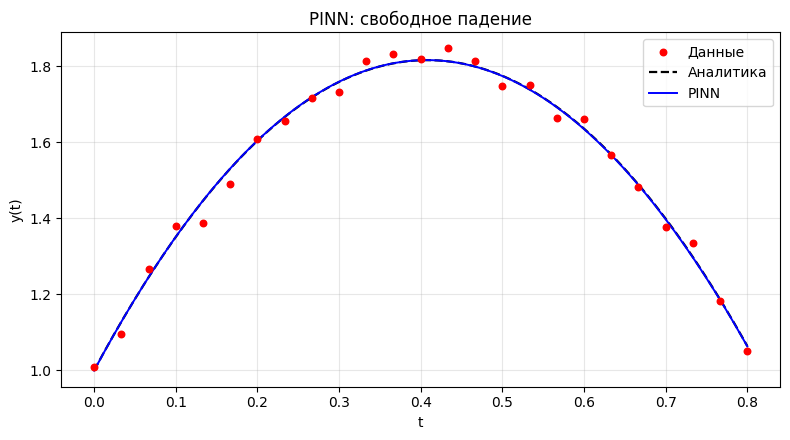

In [5]:
model.eval()
t_grid = np.linspace(float(t_data.min()), float(t_data.max()), 200)
with torch.no_grad():
    y_pred = model(torch.tensor(t_grid, dtype=torch.float32).view(-1, 1)).numpy().ravel()
plot_solution(t_data, y_np, t_grid, analytical(t_grid), y_pred, ylabel="y(t)", title="PINN: свободное падение")
